# Lab 1 — Convolution and classical filtering

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kleinric/cv-labs/blob/main/lab-01.ipynb)

**COMS4036A / COMS7050A Computer Vision · Week 1**

**Due: Thursday 30 July 2026, 17:00.** Groups of up to three; one member submits the group's notebook (`.ipynb`) on Moodle. Every member must be able to explain every cell.

Companion reading is [Chapter 1 of the course book](https://courses.ms.wits.ac.za/~richard/cv/book/). The chapter's widgets run most of this lab's operations interactively — use them to check your intuition against your code.

The Friday session covers Sections 0–5; Sections 6–8 are the take-home half. Labs are marked for completeness, correctness, and presentation: a notebook that runs top to bottom, with each written answer in its marked cell.

## 0. Working in Colab

This notebook is designed for [Google Colab](https://colab.research.google.com). Open it with the badge above — or download it from the book and **File ▸ Upload notebook**. Then, before anything else, **File ▸ Save a copy in Drive** — otherwise your work is not being saved.

Colab gives you a machine in the cloud with Python and the scientific stack preinstalled. Two things about it to learn today:

**Runtimes.** Under **Runtime ▸ Change runtime type** you choose the hardware. Everything in this lab runs on the CPU; leave the runtime on CPU so you are not queueing for a GPU you will not use. From Lab 2 onward the GPU matters, and this menu is where you will claim one.

**State.** Cells execute in the order *you run them*, not the order they appear, and variables live in the kernel between runs. A notebook that works because of a cell you ran three edits ago and then deleted is broken — you just cannot see it yet. The fix is a habit: **Runtime ▸ Restart session and run all**, then read every cell's output. Do this before you submit; a notebook that does not run top to bottom loses marks.

In [2]:
# Group members — fill in before submitting.
MEMBERS = [
    # ("Student name", "Student number"),
    ( "Nkosenhle Ndlovu", "2539199" )
]

for name, number in MEMBERS:
    print(f"{number}  {name}")

2539199  Nkosenhle Ndlovu


In [3]:
# Where is this running? On a CPU runtime, nvidia-smi fails — that is the
# expected output today.
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [4]:
import sys
import numpy as np
print(sys.version)
print("numpy", np.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy 2.0.2


## 1. Setup

The lab runs on the same images as the book: the dog-and-ball scene that every Chapter 1 figure uses, and the bark and grass textures from the texton section.

In [5]:
BASE = "https://courses.ms.wits.ac.za/~richard/cv/book/widgets/assets"
!wget -q {BASE}/scene-480.jpg {BASE}/bark.png {BASE}/grass.png
!ls -l scene-480.jpg bark.png grass.png

-rw-r--r-- 1 root root 12873 Jul 27 21:06 bark.png
-rw-r--r-- 1 root root 14960 Jul 27 21:06 grass.png
-rw-r--r-- 1 root root 59170 Jul 27 21:06 scene-480.jpg


In [7]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from skimage import color, io

plt.rcParams["figure.dpi"] = 90


def show(*images, titles=None, cmap="gray", size=3.2):
    """Display images side by side. Grayscale images are shown with
    vmin=0, vmax=1 — without that, imshow rescales each image to its own
    range and two images become impossible to compare."""
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    axes = np.atleast_1d(axes)
    for k, (ax, im) in enumerate(zip(axes, images)):
        if im.ndim == 2:
            ax.imshow(np.clip(im, 0, 1), cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(im)
        ax.set_axis_off()
        if titles:
            ax.set_title(titles[k], fontsize=9)
    plt.tight_layout()
    plt.show()

## 2. An image is an array

Load the scene and look at what `imread` actually hands you.

(322, 480, 3) uint8 0 255


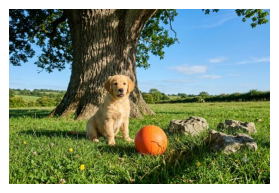

In [8]:
img = io.imread("scene-480.jpg")
print(img.shape, img.dtype, img.min(), img.max())
show(img)

**Q2.1.** From the shape alone: which axis is rows, which is columns, which is colour? Print the pixel at row 100, column 200, and say which of its three numbers is the red value.

In [10]:
# YOUR CODE HERE
img[99, 199]

array([133, 121,  95], dtype=uint8)

*Answer:* Considering the shape of `img`, the first axis is the rows, the second axis is the column and the colour channel is the third axis, in this case it is the RGB channel. The `133` value from `array([133, 121,  95], dtype=uint8)` is the red value.

**Q2.2.** Using slicing only — no loops — display the top-left quarter of the image, and the green channel of the full image as a grayscale picture.

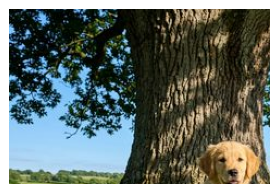

In [16]:
# YOUR CODE HERE

# half x dimension
h_x = (int) (img.shape[0] / 2)

# half y dimension
h_y = (int) (img.shape[1] / 2)

top_left_img = img[0:h_x, 0:h_y]

show(top_left_img)

### The `uint8` trap

The image arrived as `uint8`: integers 0–255, and arithmetic that wraps around silently.

In [17]:
print(np.uint8(200) + np.uint8(100))

44


/tmp/ipykernel_4078/44624559.py:1: RuntimeWarning: overflow encountered in scalar add
  print(np.uint8(200) + np.uint8(100))


**Q2.3.** Brighten the image by adding 60 — directly on the `uint8` array — and display the result. Describe what you see and explain it. Then count how many values in the array wrapped around.

In [ ]:
# YOUR CODE HERE

brightened_image = img[]

*Answer:*

This bug is why the first thing done to any image in this course is a cast:

In [ ]:
imgf = img.astype(np.float64) / 255.0   # floats in [0, 1]
gray = color.rgb2gray(img)              # grayscale, also floats in [0, 1]
print(imgf.dtype, imgf.min(), imgf.max(), "|", gray.shape)

**Q2.4.** Redo the brightening on `imgf` (add 60/255). Floats do not wrap — but some values now exceed 1. What does `show` do about them? Then check: is this brightening reversible — does subtracting 60/255 recover the original exactly (`np.allclose`)? Contrast that with Q2.3, and say where information *would* be lost if you saved this brightened image to an ordinary 8-bit file. Compare the histograms of the image before and after using `plt.hist(x.ravel(), bins=256)`.

In [ ]:
# YOUR CODE HERE

*Answer:*

## 3. Point operations

A point operation is a function applied to each pixel value independently: $v \mapsto f(v)$. Brightness is where the histogram sits — the mean $\mu$; contrast is how spread it is — the standard deviation $\sigma$. Each of these is a NumPy one-liner on `gray`.

**Q3.1.** Compute $\mu$ and $\sigma$ of `gray`. Then implement each of the following, display the result beside the original, and report the new $\mu$ and $\sigma$:

- brightness shift: $f(v) = v + b$ with $b = 0.2$
- contrast about the midpoint: $f(v) = \alpha(v - 0.5) + 0.5$ with $\alpha = 1.8$
- gamma: $f(v) = v^{1/2.2}$

In [ ]:
# YOUR CODE HERE

**Q3.2.** Check the claims of the book's §1.2 numerically: which of the three operations moved $\mu$ and left $\sigma$ alone, which scaled $\sigma$, and did any keep both? Where does clipping enter — push $\alpha$ to 4 and look at the histogram.

*Answer:*

**Q3.3.** Contrast stretch: map the image's actual range onto $[0,1]$ with $f(v) = (v - v_{\min}) / (v_{\max} - v_{\min})$. Apply it to a low-contrast version of the image (`0.3 * gray + 0.35`) and confirm it restores the full range.

In [ ]:
# YOUR CODE HERE

**Q3.4.** Histogram equalisation. The stretch fixes the range but not the shape; equalisation remaps values so the histogram becomes as flat as the data allows. The recipe: histogram the values into 256 bins, take the cumulative sum, normalise it to $[0,1]$ — that cumulative curve *is* the transfer function. Apply it with `np.interp`:

In [ ]:
hist, bin_edges = np.histogram(gray, bins=256, range=(0, 1))
# YOUR CODE HERE — build the normalised cumulative sum, then
# eq = np.interp(gray, bin_edges[1:], cdf)

Display the image before and after, with both histograms. Where in the scene did equalisation spend its effort?

*Answer:*

## 4. Convolution from scratch

Everything after this point in the course — every filter in this lab, every layer of every network from Lab 2 onward — is this operation. Write it once yourself, by hand, so that it is never a mystery:

$$(I * K)(i, j) = \sum_{m}\sum_{n} I(i - m,\; j - n)\, K(m, n)$$

The index arithmetic ($i-m$, not $i+m$) means the kernel is *flipped* before it slides — that is what makes this convolution rather than correlation.

**Q4.1.** Implement `conv2(image, K)`: zero-pad the image so the output has the same height and width, flip the kernel, and slide. Two nested loops over output pixels, with a vectorised multiply-and-sum inside, is the intended solution — no `scipy` inside the function.

In [ ]:
def conv2(image, K):
    # YOUR CODE HERE
    ...

In [ ]:
# Verification — run unchanged. Passes silently or fails loudly.
rng = np.random.default_rng(0)
A = rng.random((32, 32))
K = rng.random((5, 3))
assert np.allclose(conv2(A, K), ndimage.convolve(A, K, mode="constant")), \
    "conv2 does not match scipy — check padding and the kernel flip"
print("conv2 matches scipy.ndimage.convolve")

**Q4.2.** `ndimage.correlate` is the same sliding window without the flip. Apply both your `conv2` and `ndimage.correlate` to `gray` with the Sobel kernel below and compare the outputs. Why do symmetric kernels hide this difference, and what does that mean for a blur?

In [ ]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
# YOUR CODE HERE

*Answer:*

**Q4.3.** Build a normalised $5\times5$ box kernel and a $31\times31$ Gaussian kernel with $\sigma = 5$ (construct the 1D Gaussian from its formula, then take the outer product). Blur `gray` with each — `ndimage.convolve` is allowed from here on, your `conv2` has earned it — and display the results side by side. Where do the box's streaky artefacts show?

In [ ]:
# YOUR CODE HERE

*Answer:*

**Q4.4.** Separability. The Gaussian factors: filtering rows with the 1D kernel, then columns, equals the 2D convolution. Verify the outputs match (`np.allclose`), then time the two with `time.perf_counter` — average over a few runs. The operation-count argument predicts $961/62 \approx 15\times$; what do you measure, and why might the wall-clock ratio differ?

In [ ]:
# YOUR CODE HERE

*Answer:*

**Q4.5.** Gradients. Convolve `gray` with `sobel_x` and its transpose to get $g_x$ and $g_y$, then compute the gradient magnitude $\sqrt{g_x^2 + g_y^2}$ and orientation (`np.arctan2(gy, gx)`). Display the magnitude (rescale it into $[0,1]$ for display). Which edges in the scene answer to $g_x$ but not $g_y$?

In [ ]:
# YOUR CODE HERE

*Answer:*

## 5. The noise film-strip

Additive Gaussian noise perturbs every pixel independently:

$$x_{ij} \leftarrow x_{ij} + \varepsilon, \qquad \varepsilon \sim N(0, \sigma^2)$$

Against values in $[0,1]$, $\sigma$ has direct meaning: at $\sigma = 0.05$ a typical pixel is off by a twentieth of the full range; at $\sigma = 0.5$ the noise is as strong as the signal.

**Q5.1.** Implement `add_noise(image, sigma, rng)`. Do **not** clip the result — keep the true noisy values and let `show` clip for display only. Build the film-strip: `gray` at the six waypoints $\sigma \in \{0,\ 0.05,\ 0.1,\ 0.2,\ 0.5,\ 1.0\}$, displayed as one row, clean to pure static, each panel titled with its $\sigma$.

In [ ]:
WAYPOINTS = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]

def add_noise(image, sigma, rng):
    # YOUR CODE HERE
    ...

# YOUR CODE HERE — build and display the strip

**Q5.2.** Noise adds variance: $\mathrm{Var}(x + \varepsilon) = \mathrm{Var}(x) + \sigma^2$. Verify this numerically at each waypoint. The signal-to-noise ratio in decibels is $10 \log_{10}(\mathrm{Var}(x) / \sigma^2)$ — report it for each waypoint too.

In [ ]:
# YOUR CODE HERE

Save the strip — the array, not just the picture:

In [ ]:
strip = np.stack([add_noise(gray, s, np.random.default_rng(1)) for s in WAYPOINTS])
np.savez("filmstrip.npz", sigmas=np.array(WAYPOINTS), strip=strip)
!ls -l filmstrip.npz

The strip is this lab's test bench — Sections 6 and 7 run the chapter's detectors down it. It is also the first piece of something larger: **keep `filmstrip.npz` somewhere durable** (download it, or copy it into your Drive). A later lab asks for the file, and for the `add_noise` function that made it.

In [ ]:
from google.colab import files
files.download("filmstrip.npz")

## 6. Edges on the strip

How does Canny behave as the noise rises? `skimage.feature.canny` runs the whole pipeline — Gaussian smooth, gradient, non-maximum suppression, hysteresis — with the smoothing scale as `sigma` (this is a *different* $\sigma$ from the noise level; keep the two apart).

In [ ]:
from skimage.feature import canny

NOISE = [0.0, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5]

**Q6.1.** For each noise level in `NOISE`, run `canny(noisy, sigma=2)` and count the edge pixels (`edges.sum()`). Plot the count against noise level. The count *rises*. Look at the edge maps for $\sigma = 0$ and $\sigma = 0.3$ side by side and explain why counting edge pixels cannot measure edge survival.

In [ ]:
# YOUR CODE HERE

*Answer:*

One tool you have not met yet: **dilation**. On a binary image, one step of dilation turns on every pixel that touches a `True` pixel, so a shape grows one pixel fatter all round. The cell below shows it on a toy array — three pixels become a thickened bar:

In [ ]:
toy = np.zeros((5, 7), dtype=bool)
toy[2, 2:5] = True
print(toy.astype(int))
print()
print(ndimage.binary_dilation(toy).astype(int))

**Q6.2.** A metric that can: **precision against the clean edges**. Take the clean edge map and dilate it by one pixel, so that a detection landing one pixel off a clean edge still counts. Then measure the fraction of *detected* edge pixels that land inside the dilated map:

$$\text{precision} = \frac{|\,\text{detected} \cap \text{dilated clean}\,|}{|\,\text{detected}\,|}$$

Compute precision across `NOISE` for `canny` at smoothing $\sigma \in \{1, 2, 4\}$ (each against its own clean map) and plot the three curves on one set of axes.

In [ ]:
# YOUR CODE HERE

**Q6.3.** Read your plot. Which curve collapses first? Smoothing more delays the collapse — what does $\sigma = 4$ cost on the *clean* image? (Display the three clean edge maps.) One caution before crediting $\sigma = 1$ with its floor of ${\sim}0.6$: what fraction of the whole image is within one pixel of a $\sigma = 1$ clean edge, and what does that make the chance level of this metric?

In [ ]:
# YOUR CODE HERE

*Answer:*

## 7. SIFT on the strip

SIFT finds keypoints and describes their neighbourhoods so that the same physical point can be matched between two photographs — across rotation and scale. The book's matching figure pairs the scene with a rotated, rescaled copy of itself; do the same, then let the copy degrade.

In [ ]:
from skimage.feature import SIFT, match_descriptors
from skimage.transform import rescale, rotate

view2 = rescale(rotate(gray, 22, resize=True), 0.75)
show(gray, view2, titles=["view 1", "view 2: rotated 22°, rescaled 0.75"])

**Q7.1.** Detect and match. `SIFT().detect_and_extract(image)` fills `.keypoints` and `.descriptors`; `match_descriptors(d1, d2, max_ratio=0.72, cross_check=True)` applies the ratio test both ways. How many keypoints on each view, and how many matches survive between the clean pair?

In [ ]:
# YOUR CODE HERE

**Q7.2.** Now run the noise down the strip: for each level in `NOISE`, add noise to `view2` (clip to $[0,1]$ this time — SIFT expects an image), re-detect, re-match against the *clean* first view, and record the match count. Plot match count against noise level. Wrap `detect_and_extract` in `try/except RuntimeError` and record zero if it fails — at high noise there may be nothing left to detect.

In [ ]:
# YOUR CODE HERE

**Q7.3.** At what noise level have half the clean pair's matches gone? Compare with the Canny curves of Q6.2: is descriptor matching more or less robust to this noise than edge detection, and why might averaging over a $16\times16$ neighbourhood help?

*Answer:*

## 8. Textons and Bag-of-Visual-Words

The chapter's texture pipeline, end to end, on the book's bark and grass: *filter* with a bank, *describe* each pixel by its responses, *cluster* the descriptions into a vocabulary of textons, *count* the vocabulary — then classify.

In [ ]:
from scipy.cluster.vq import kmeans2
from skimage.filters import gabor_kernel

bark = io.imread("bark.png").astype(np.float64) / 255.0
grass = io.imread("grass.png").astype(np.float64) / 255.0
show(bark, grass, titles=["bark", "grass"])

**Q8.1.** Build the bank: Gabor kernels at three frequencies $f \in \{0.1, 0.2, 0.4\}$ and four orientations $\theta \in \{0°, 45°, 90°, 135°\}$ — twelve kernels. `gabor_kernel(frequency, theta=...)` returns a complex kernel; display the real parts as one $3\times4$ grid of images. Match what you see against the Gabor formula: which way does $\theta$ turn the stripes, and what does $f$ change?

In [ ]:
# YOUR CODE HERE

*Answer:*

**Q8.2.** Filter. For each kernel, the response magnitude is $\sqrt{(I * \mathrm{Re}\,K)^2 + (I * \mathrm{Im}\,K)^2}$ — convolve with the real and imaginary parts separately (`ndimage.convolve`, `mode="nearest"`) and combine. Write `responses(image)` returning an `H × W × 12` array, and run it on both textures. Display a few response channels: which kernels fire on bark, which on grass?

In [ ]:
def responses(image):
    # YOUR CODE HERE
    ...

*Answer:*

**Q8.3.** Cluster. Each pixel is now a 12-dimensional vector. Use only the **left half** (columns 0–63) of each texture — the right halves stay unseen for testing. Pool the left-half pixels of both textures, sample 4 000 of them, and cluster with `kmeans2(sample, k=8, seed=3, minit="++")`. The eight centroids are the texton vocabulary.

In [ ]:
# YOUR CODE HERE

**Q8.4.** Map and count. Assign every pixel of each texture to its nearest texton and display the two texton maps (`imshow` with `cmap="tab10"`). Then write `texton_hist(patch_responses)`: nearest-texton label per pixel, count into 8 bins, normalise to sum to 1. Plot the histogram of each texture's left half as a bar chart — the two signatures the classifier will lean on.

In [ ]:
# YOUR CODE HERE

**Q8.5.** Classify. Cut each half into $32\times32$ crops — eight training crops per texture from the left halves, eight test crops per texture from the right. Histogram every crop; classify each test crop by its nearest training histogram under the $\chi^2$ distance

$$\chi^2(h, g) = \tfrac{1}{2}\sum_k \frac{(h_k - g_k)^2}{h_k + g_k + \epsilon}$$

and report accuracy out of 16, with the label of any crop that misses.

In [ ]:
# YOUR CODE HERE

**Q8.6.** The histogram threw away *where* every texton fell. For texture, that loss is the point — say why. Name one recognition task from the chapter where discarding all spatial layout would be fatal.

*Answer:*

## 9. Before you submit

- [ ] **Runtime ▸ Restart session and run all** — then read every output, top to bottom.
- [ ] Group members filled in at the top; every member can explain every cell.
- [ ] Every *Answer:* cell has an answer in it.
- [ ] `filmstrip.npz` is saved somewhere you will find it later in the semester.
- [ ] **File ▸ Download ▸ Download .ipynb**, and one member submits it on Moodle before **Thursday 30 July, 17:00**.